[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nisheshgogia/vorithm-interview-questions-solutions/blob/main/Python/trees/trees.ipynb)

# 1.Binary Tree Level-Order Traversal (BFS)

# Difficulty: 🟡 Medium
Problem Statement:
```
Given the root of a binary tree, return the level order traversal of its nodes' values (i.e., from left to right, level by level).

Example 1:
Input: root = [3,9,20,null,null,15,7]

Output: [[3],[9,20],[15,7]]

Visualization:
    3
   / \
  9  20
     / \
    15  7
Level 0: [3]
Level 1: [9, 20]
Level 2: [15, 7]
```
Example 2:
Input: root = [1]
Output: [[1]]

```
Example 3:
Input: root = []
Output: []

In [1]:
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

#Brute Force Approach (Recursive DFS with Level Tracking)
def level_order_brute(root):
    if not root:
        return []

    result = []

    def dfs(node, level):
        if not node:
            return

        # Ensure result has enough levels
        if level >= len(result):
            result.append([])

        # Add current node to its level
        result[level].append(node.val)

        # Recurse on children with incremented level
        dfs(node.left, level + 1)
        dfs(node.right, level + 1)

    dfs(root, 0)
    return result

# Example
root = TreeNode(3)
root.left = TreeNode(9)
root.right = TreeNode(20)
root.right.left = TreeNode(15)
root.right.right = TreeNode(7)

print(level_order_brute(root))  # Output: [[3],[9,20],[15,7]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even balanced tree must visit all n nodes
#                DFS visits each node exactly once
# avg   → O(n) : recursive calls: each of n nodes visited once
#                each visit does O(1) work (append to list)
#                total = n × O(1) = O(n)
# worst → O(n) : skewed tree (all left or all right) still visits n nodes
#                recursion depth = O(n) for skewed tree
# space → O(n) : result stores all n nodes
#                recursion stack: O(h) where h = height
#                worst case h = n (skewed), best case h = log n (balanced)
#                total space = O(n) for result + O(h) for stack

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)


[[3], [9, 20], [15, 7]]


In [2]:
#Optimized Approach (Iterative BFS with Queue)
from collections import deque

def level_order_optimized(root):
    if not root:
        return []

    result = []
    queue = deque([root])

    while queue:
        level_size = len(queue)
        current_level = []

        # Process all nodes at current level
        for _ in range(level_size):
            node = queue.popleft()
            current_level.append(node.val)

            # Add children to queue for next level
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)

        result.append(current_level)

    return result

print(level_order_optimized(root))  # Output: [[3],[9,20],[15,7]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even single node requires queue operations
#                must visit all nodes to ensure completeness
# avg   → O(n) : each of n nodes enqueued once and dequeued once
#                each node: O(1) dequeue + O(1) append children
#                total = n × O(1) = O(n)
# worst → O(n) : complete binary tree: all nodes at each level processed
#                last level has n/2 nodes all in queue simultaneously
# space → O(n) : result stores all n nodes
#                queue holds at most one full level
#                worst case: complete tree's last level = n/2 nodes = O(n)

# BFS is more intuitive for level-order traversal!
# DFS requires tracking levels manually

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)



[[3], [9, 20], [15, 7]]


## 2. Maximum Depth of Binary Tree
**Difficulty: 🟢 Low**

**Problem Statement:**
Given the root of a binary tree, return its maximum depth.

The maximum depth is the number of nodes along the longest path from the root node down to the farthest leaf node.

**Example 1:**
```
Input: root = [3,9,20,null,null,15,7]
Output: 3
Visualization:
    3
   / \
  9  20
     / \
    15  7
Depth = 3 (path: 3 → 20 → 15 or 3 → 20 → 7)
```

**Example 2:**
```
Input: root = [1,null,2]
Output: 2
```

**Example 3:**
```
Input: root = []
Output: 0

In [3]:
#Brute Force Approach (Level-Order Traversal, Count Levels)
def max_depth_brute(root):
    if not root:
        return 0

    from collections import deque
    queue = deque([root])
    depth = 0

    while queue:
        depth += 1
        level_size = len(queue)

        for _ in range(level_size):
            node = queue.popleft()
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)

    return depth

# Example
root = TreeNode(3)
root.left = TreeNode(9)
root.right = TreeNode(20)
root.right.left = TreeNode(15)
root.right.right = TreeNode(7)

print(max_depth_brute(root))  # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even single node requires queue operations
#                cannot determine depth without visiting all nodes
# avg   → O(n) : BFS visits every node once
#                each level processed: dequeue + enqueue children = O(1) per node
#                total = n × O(1) = O(n)
# worst → O(n) : complete binary tree requires full traversal
#                all n nodes visited to count depth
# space → O(n) : queue holds one complete level at a time
#                worst case: last level of complete tree = n/2 nodes = O(n)

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)


3


In [5]:
#Optimized Approach (Recursive DFS - More Elegant)
def max_depth_optimized(root):
    if not root:
        return 0

    # Depth = 1 (current node) + max depth of subtrees
    left_depth = max_depth_optimized(root.left)
    right_depth = max_depth_optimized(root.right)

    return 1 + max(left_depth, right_depth)

print(max_depth_optimized(root))  # Output: 3

# One-liner version:
def max_depth_oneliner(root):
    return 0 if not root else 1 + max(max_depth_oneliner(root.left),
                                       max_depth_oneliner(root.right))

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even for single node, must check if children exist
#                recursive calls still made (base case returns immediately)
# avg   → O(n) : each of n nodes visited exactly once
#                each visit: two recursive calls + one comparison = O(1)
#                recurrence: T(n) = T(left) + T(right) + O(1) = O(n)
# worst → O(n) : skewed tree: recursion goes n levels deep
#                still visits all n nodes once
# space → O(h) : recursion stack depth = tree height h
#                best case (balanced): h = log n
#                worst case (skewed): h = n

# KEY INSIGHT: depth = 1 + max(left_depth, right_depth)
# This is more elegant and space-efficient than BFS for depth calculation

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(h) where h = height (O(log n) balanced, O(n) skewed)


3






---

## 3. Check if Binary Tree is Symmetric
**Difficulty: 🟢 Low**

**Problem Statement:**
Given the root of a binary tree, check whether it is symmetric around its center (i.e., it is a mirror of itself).

**Example 1:**
```
Input: root = [1,2,2,3,4,4,3]
Output: true
Visualization:
      1
     / \
    2   2
   / \ / \
  3  4 4  3
Mirror symmetric ✓
```

**Example 2:**
```
Input: root = [1,2,2,null,3,null,3]
Output: false
Visualization:
    1
   / \
  2   2
   \   \
    3   3
Not symmetric (both 3s on right side)
```

**Example 3:**
```
Input: root = [1]
Output: true

In [6]:
#Brute Force Approach (Level-Order Traversal, Check Palindrome)
def is_symmetric_brute(root):
    if not root:
        return True

    from collections import deque
    queue = deque([root])

    while queue:
        level_size = len(queue)
        level_vals = []

        # Collect all values at current level (including None)
        for _ in range(level_size):
            node = queue.popleft()
            if node:
                level_vals.append(node.val)
                queue.append(node.left)
                queue.append(node.right)
            else:
                level_vals.append(None)

        # Check if level is palindrome
        if level_vals != level_vals[::-1]:
            return False

    return True

# Example
root = TreeNode(1)
root.left = TreeNode(2, TreeNode(3), TreeNode(4))
root.right = TreeNode(2, TreeNode(4), TreeNode(3))

print(is_symmetric_brute(root))  # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even if asymmetry found early, BFS setup costs O(1)
#                first level check might catch asymmetry but still O(n)
# avg   → O(n) : visit all nodes in worst case (symmetric tree)
#                each level: collect values O(level_size) + palindrome check O(level_size)
#                total nodes visited = n → O(n)
# worst → O(n) : fully symmetric tree → check all n nodes
#                last level has n/2 nodes, palindrome check O(n/2)
# space → O(n) : queue holds one level at a time: O(n/2) for last level
#                level_vals stores current level: O(n/2)

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)


True


In [7]:
#Optimized Approach (Recursive Helper - Mirror Comparison)
def is_symmetric_optimized(root):
    if not root:
        return True

    def is_mirror(left, right):
        # Both None → symmetric
        if not left and not right:
            return True

        # One None, other not → asymmetric
        if not left or not right:
            return False

        # Check: values equal AND subtrees are mirrors
        return (left.val == right.val and
                is_mirror(left.left, right.right) and   # outer pair
                is_mirror(left.right, right.left))      # inner pair

    return is_mirror(root.left, root.right)

print(is_symmetric_optimized(root))  # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1) : root has asymmetric immediate children (different values)
#                detected in first recursive call
# avg   → O(n) : each node visited once in mirror comparison
#                is_mirror called for each pair: total n/2 pairs = O(n)
# worst → O(n) : fully symmetric tree → all nodes checked
#                every node paired with its mirror → n comparisons
# space → O(h) : recursion stack depth = tree height
#                balanced tree: O(log n), skewed: O(n)

# KEY INSIGHT:
# For tree to be symmetric, left and right subtrees must be mirrors:
# - left.left mirrors right.right (outer children)
# - left.right mirrors right.left (inner children)

#best time complexity    - O(1)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(h)



True


## 4. Lowest Common Ancestor (LCA)
**Difficulty: 🟡 Medium**

**Problem Statement:**
Given a binary tree, find the lowest common ancestor (LCA) of two given nodes p and q.

The lowest common ancestor is defined as the lowest node in the tree that has both p and q as descendants (where a node can be a descendant of itself).

**Example 1:**
```
Input: root = [3,5,1,6,2,0,8,null,null,7,4], p = 5, q = 1
Output: 3
Explanation: LCA of nodes 5 and 1 is 3
Visualization:
        3
       / \
      5   1
     / \ / \
    6  2 0  8
      / \
     7   4
```

**Example 2:**
```
Input: root = [3,5,1,6,2,0,8,null,null,7,4], p = 5, q = 4
Output: 5
Explanation: LCA of 5 and 4 is 5 (node can be ancestor of itself)

In [8]:
#Brute Force Approach (Find Paths, Compare)
def lowest_common_ancestor_brute(root, p, q):
    def find_path(node, target, path):
        if not node:
            return False

        path.append(node)

        if node == target:
            return True

        if (find_path(node.left, target, path) or
            find_path(node.right, target, path)):
            return True

        path.pop()  # Backtrack
        return False

    # Find paths to both nodes
    path_p = []
    path_q = []
    find_path(root, p, path_p)
    find_path(root, q, path_q)

    # Find last common node in both paths
    lca = None
    for i in range(min(len(path_p), len(path_q))):
        if path_p[i] == path_q[i]:
            lca = path_p[i]
        else:
            break

    return lca

# Example
root = TreeNode(3)
root.left = TreeNode(5)
root.right = TreeNode(1)
root.left.left = TreeNode(6)
root.left.right = TreeNode(2)
root.left.right.left = TreeNode(7)
root.left.right.right = TreeNode(4)
root.right.left = TreeNode(0)
root.right.right = TreeNode(8)

p = root.left  # Node 5
q = root.right  # Node 1
print(lowest_common_ancestor_brute(root, p, q).val)  # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even if p and q are immediate children of root,
#                still need to find paths which requires traversal
# avg   → O(n) : find_path for p: visits O(n) nodes in worst case
#                find_path for q: visits O(n) nodes
#                path comparison: O(h) where h = height
#                total = O(n) + O(n) + O(h) = O(n)
# worst → O(n) : p and q are leaf nodes in opposite subtrees
#                both paths require full traversal
# space → O(h) : path_p and path_q store at most h nodes each
#                recursion stack: O(h)
#                total = O(h) for paths + O(h) for stack = O(h)

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(h)


3


In [10]:
#Optimized Approach (Single Pass Recursive)
def lowest_common_ancestor_optimized(root, p, q):
    # Base case: if root is None or matches p or q
    if not root or root == p or root == q:
        return root

    # Search in left and right subtrees
    left = lowest_common_ancestor_optimized(root.left, p, q)
    right = lowest_common_ancestor_optimized(root.right, p, q)

    # If both left and right are non-null, root is LCA
    if left and right:
        return root

    # Otherwise, return whichever is non-null
    return left if left else right

print(lowest_common_ancestor_optimized(root, p, q).val)  # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1) : root itself is p or q → immediate return
# avg   → O(n) : each node visited at most once
#                post-order traversal: left → right → process
#                each visit: two recursive calls + one comparison = O(1)
# worst → O(n) : p and q are leaf nodes → must traverse entire tree
#                all n nodes visited once
# space → O(h) : recursion stack depth = tree height
#                balanced: O(log n), skewed: O(n)

# KEY INSIGHT:
# If one subtree contains both p and q, that subtree's result is LCA
# If p in left and q in right (or vice versa), current node is LCA
# If neither subtree contains p or q, return null

# VISUALIZATION (p=5, q=1):
#         3          ← Both left and right return non-null → LCA is 3
#        / \
#   [5] ←   → [1]   Both found in different subtrees

#best time complexity    - O(1)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(h)

3


## 5. Validate Binary Search Tree
**Difficulty: 🟡 Medium**

**Problem Statement:**
Given the root of a binary tree, determine if it is a valid binary search tree (BST).

A valid BST is defined as follows:
- The left subtree of a node contains only nodes with keys less than the node's key
- The right subtree of a node contains only nodes with keys greater than the node's key
- Both left and right subtrees must also be binary search trees

**Example 1:**
```
Input: root = [2,1,3]
Output: true
Visualization:
    2
   / \
  1   3
Valid BST: 1 < 2 < 3
```

**Example 2:**
```
Input: root = [5,1,4,null,null,3,6]
Output: false
Visualization:
      5
     / \
    1   4
       / \
      3   6
Invalid: 3 < 5 violates BST property (3 is in right subtree of 5)

In [11]:
#Brute Force Approach (Check Each Node Against Subtree Min/Max)
def is_valid_BST_brute(root):
    def get_min(node):
        while node.left:
            node = node.left
        return node.val

    def get_max(node):
        while node.right:
            node = node.right
        return node.val

    def is_valid(node):
        if not node:
            return True

        # Check left subtree
        if node.left:
            if get_max(node.left) >= node.val:
                return False

        # Check right subtree
        if node.right:
            if get_min(node.right) <= node.val:
                return False

        # Recursively validate subtrees
        return is_valid(node.left) and is_valid(node.right)

    return is_valid(root)

# Example
root = TreeNode(2, TreeNode(1), TreeNode(3))
print(is_valid_BST_brute(root))  # Output: True

root2 = TreeNode(5)
root2.left = TreeNode(1)
root2.right = TreeNode(4, TreeNode(3), TreeNode(6))
print(is_valid_BST_brute(root2))  # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2) : even balanced tree requires checking each node
#                  get_min/get_max called at each node
# avg   → O(n^2) : for each of n nodes, get_min/get_max may traverse h nodes
#                  each node: O(h) for min/max check
#                  total = n × O(h) = O(n × log n) balanced, O(n^2) skewed
# worst → O(n^2) : skewed tree: each node checks entire subtree
#                  first node: O(n), second: O(n-1), ... = n(n+1)/2 = O(n^2)
# space → O(h)   : recursion stack depth = height

#best time complexity    - O(n^2)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(h)

True
False


In [12]:
#Optimized Approach (Range Validation - Pass Min/Max Bounds)
def is_valid_BST_optimized(root):
    def validate(node, min_val, max_val):
        if not node:
            return True

        # Current node must be within valid range
        if node.val <= min_val or node.val >= max_val:
            return False

        # Left subtree: must be < node.val (update max bound)
        # Right subtree: must be > node.val (update min bound)
        return (validate(node.left, min_val, node.val) and
                validate(node.right, node.val, max_val))

    return validate(root, float('-inf'), float('inf'))

print(is_valid_BST_optimized(root))   # Output: True
print(is_valid_BST_optimized(root2))  # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : root violates BST property immediately
#                  e.g., left child > root
# avg   → O(n)   : each node visited exactly once
#                  each visit: two recursive calls + one comparison = O(1)
#                  no repeated subtree traversals
# worst → O(n)   : valid BST → must check all n nodes
#                  single pass through entire tree
# space → O(h)   : recursion stack = tree height
#                  balanced: O(log n), skewed: O(n)

# KEY INSIGHT:
# Instead of checking each node against its subtree's min/max,
# propagate valid range down the tree:
# - Root can be anything: (-∞, +∞)
# - Left child of node x: (-∞, x)
# - Right child of node x: (x, +∞)

# VISUALIZATION (valid BST):
#         5 (-∞, +∞)
#        / \
#   2(-∞,5)  7(5,+∞)
#   /   \    /   \
# 1(-∞,2) 3(2,5) 6(5,7) 8(7,+∞)

#best time complexity    - O(1)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(h)

True
False


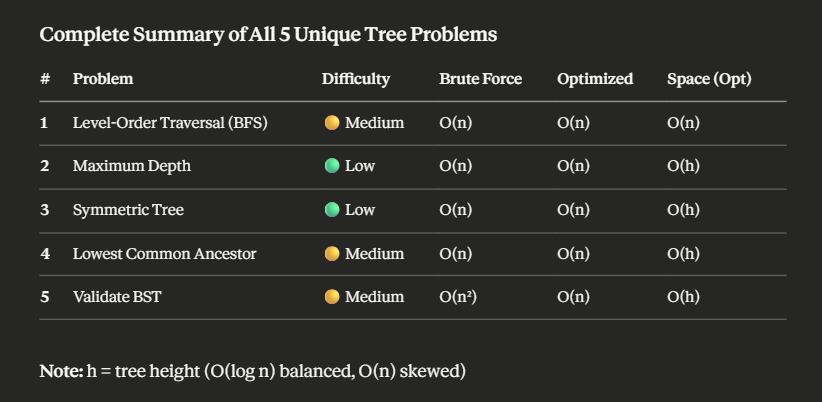